In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xarray as xr
import os
import glob
import calendar

In [ ]:
# Define file path of data
regional_file_path = '/content/drive/My Drive/capstone_data/region_avg_month_ts/chirps-v2.0.monthly.nc'
# Load the dataset (CDS)
regional_data = xr.open_dataset(regional_file_path)


In [ ]:
# View regional data as dataframe
time_series_data = regional_data['precip']

In [ ]:
min_lon = 29
max_lon = 36
min_lat = 1.5
max_lat = 4

lake_victoria_data = time_series_data.sel(latitude=slice(min_lat, max_lat), longitude=slice(min_lon, max_lon))
lake_victoria_time_series = lake_victoria_data.mean(dim=['latitude', 'longitude']).to_series()

lake_victoria_data = lake_victoria_data.to_dataframe().reset_index()
lake_victoria_data


,time,latitude,longitude,precip
0,1981-01-01,1.524998,29.024994,28.936699
1,1981-01-01,1.524998,29.074997,28.685741
2,1981-01-01,1.524998,29.125000,28.365891
3,1981-01-01,1.524998,29.175003,28.490667
4,1981-01-01,1.524998,29.224991,28.693373
...,...,...,...,...
3695995,2024-12-01,3.974998,35.774994,5.959158
3695996,2024-12-01,3.974998,35.824997,6.253981
3695997,2024-12-01,3.974998,35.875000,5.768549
3695998,2024-12-01,3.974998,35.925003,5.217360


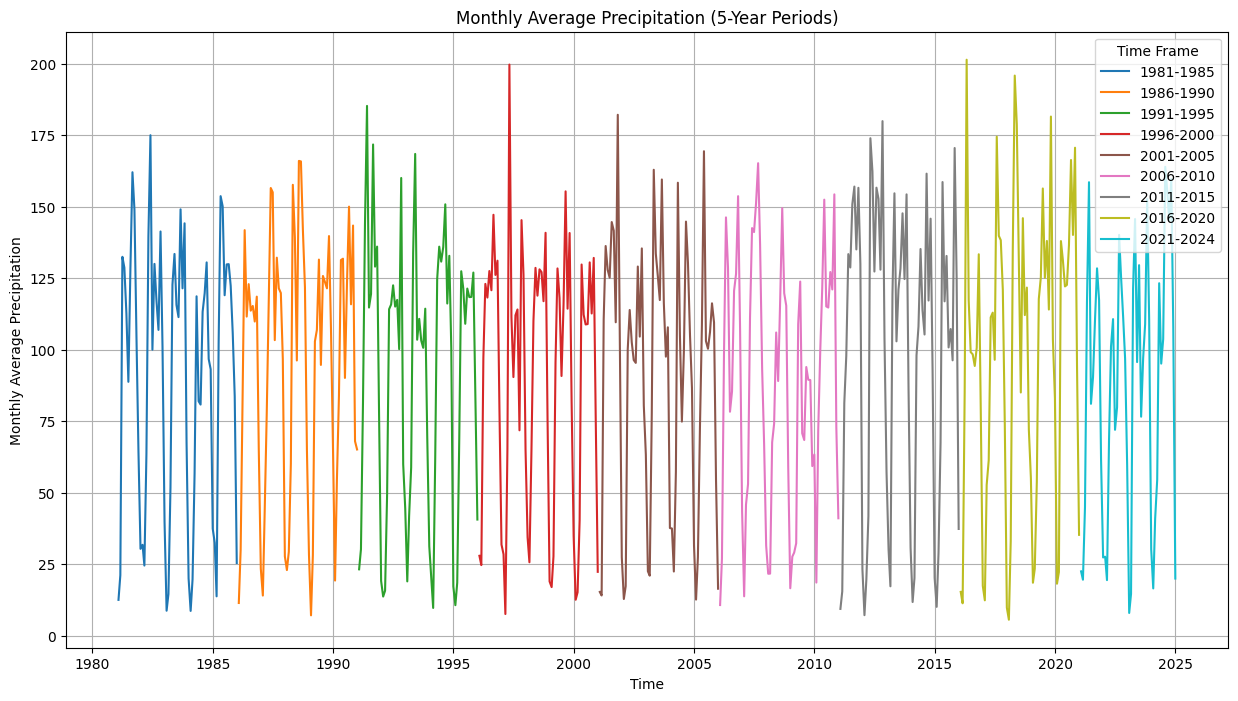

In [ ]:
# Define the time frames for each 5-year period
time_frames = [
    ('1981-01-01', '1985-12-31'),
    ('1986-01-01', '1990-12-31'),
    ('1991-01-01', '1995-12-31'),
    ('1996-01-01', '2000-12-31'),
    ('2001-01-01', '2005-12-31'),
    ('2006-01-01', '2010-12-31'),
    ('2011-01-01', '2015-12-31'),
    ('2016-01-01', '2020-12-31'),
    ('2021-01-01', '2024-12-31')
]

# Colors for each time frame
colors = plt.cm.tab10(np.linspace(0, 1, len(time_frames)))

# Plotting
plt.figure(figsize=(15, 8))

for i, (start_date, end_date) in enumerate(time_frames):
    # Filter data for the time frame
    period_data = lake_victoria_time_series[start_date:end_date]

    # Calculate monthly average precipitation
    monthly_avg = period_data.resample('ME').mean()

    # Plotting the time series for each period
    plt.plot(monthly_avg.index, monthly_avg.values, color=colors[i], label=f'{start_date[:4]}-{end_date[:4]}')

plt.xlabel('Time')
plt.ylabel('Monthly Average Precipitation')
plt.title('Monthly Average Precipitation (5-Year Periods)')
plt.legend(title='Time Frame')
plt.grid(True)
plt.show()


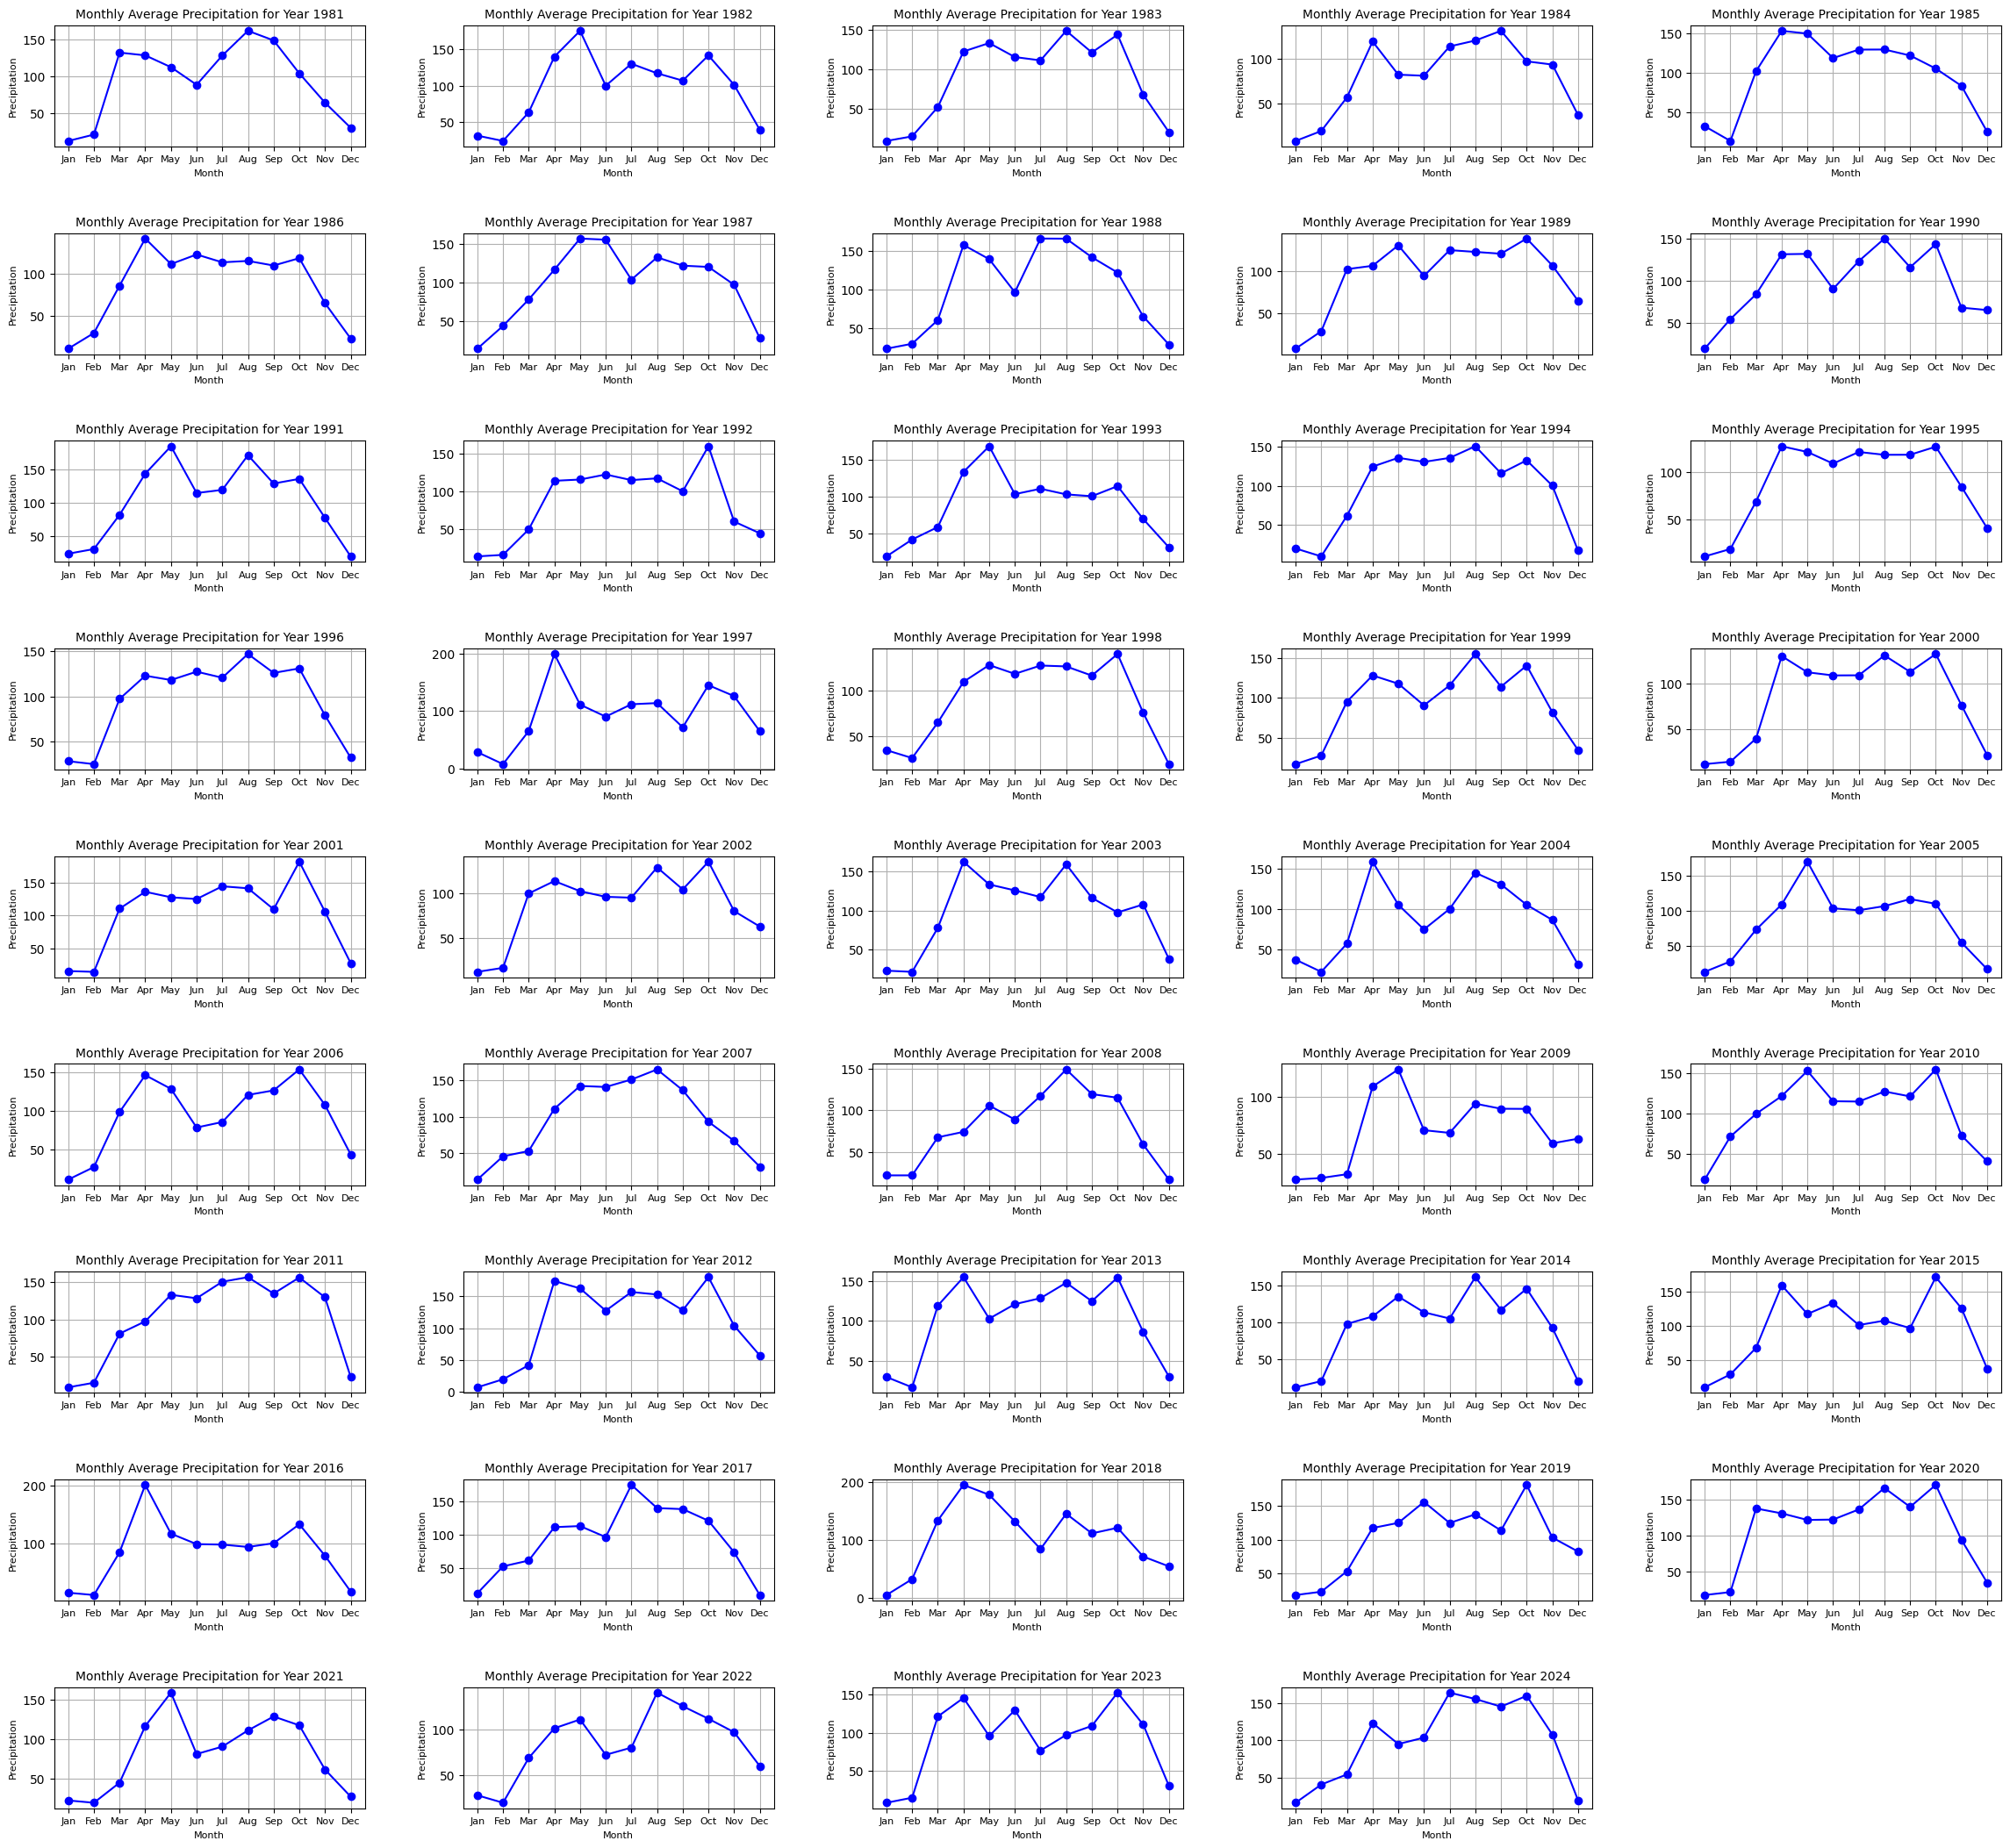

In [ ]:
### Mean Precip.

# Extract year and month from the 'time' column
lake_victoria_data['year'] = lake_victoria_data['time'].dt.year
lake_victoria_data['month'] = lake_victoria_data['time'].dt.month

# Now, we can group by 'year' and 'month' and plot
unique_years = lake_victoria_data['year'].unique()

# Create a 9x5 matrix of subplots
fig, axes = plt.subplots(nrows=9, ncols=5, figsize=(24, 22))
fig.tight_layout(pad=5.0)  # Adjust spacing between subplots

# Flatten the axes array for easier iteration
axes = axes.flatten()

for idx, year in enumerate(unique_years):
    # Filter data for the current year
    year_data = lake_victoria_data[lake_victoria_data['year'] == year]

    # Group by month and calculate the mean precipitation for that month
    monthly_mean_precip = year_data.groupby('month')['precip'].mean()

    # Plot the data on the corresponding axis
    ax = axes[idx]
    ax.plot(monthly_mean_precip.index, monthly_mean_precip.values, marker='o', linestyle='-', color='b')

    # Add labels and title
    ax.set_title(f'Monthly Average Precipitation for Year {year}', fontsize=10)
    ax.set_xlabel('Month', fontsize=8)
    ax.set_ylabel('Precipitation', fontsize=8)

    # Set x-axis labels as month names
    ax.set_xticks(monthly_mean_precip.index)
    ax.set_xticklabels(["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"], fontsize=8)

    # Show grid for better readability
    ax.grid(True)

# Hide unused subplots if there are fewer than 42 years
for i in range(len(unique_years), len(axes)):
    axes[i].axis('off')

plt.show()

In [ ]:
df = lake_victoria_data.copy()

In [ ]:
# Correlation between Precipitation and Time (Year)
df['year'] = df['time'].dt.year  # Extract the year from time
correlation_time = df[['year', 'precip']].corr()

# Display the correlation matrix for time vs precipitation
print("Correlation between Year and Precipitation:")
print(correlation_time)

# Correlation between Precipitation and Latitude/Longitude
correlation_geo = df[['latitude', 'longitude', 'precip']].corr()

# Display the correlation matrix for latitude/longitude vs precipitation
print("\nCorrelation between Latitude, Longitude, and Precipitation:")
print(correlation_geo)


Correlation between Year and Precipitation:
            year    precip
year    1.000000  0.011147
precip  0.011147  1.000000

Correlation between Latitude, Longitude, and Precipitation:
               latitude     longitude    precip
latitude   1.000000e+00 -9.625328e-17 -0.074095
longitude -9.625328e-17  1.000000e+00 -0.458024
precip    -7.409494e-02 -4.580236e-01  1.000000


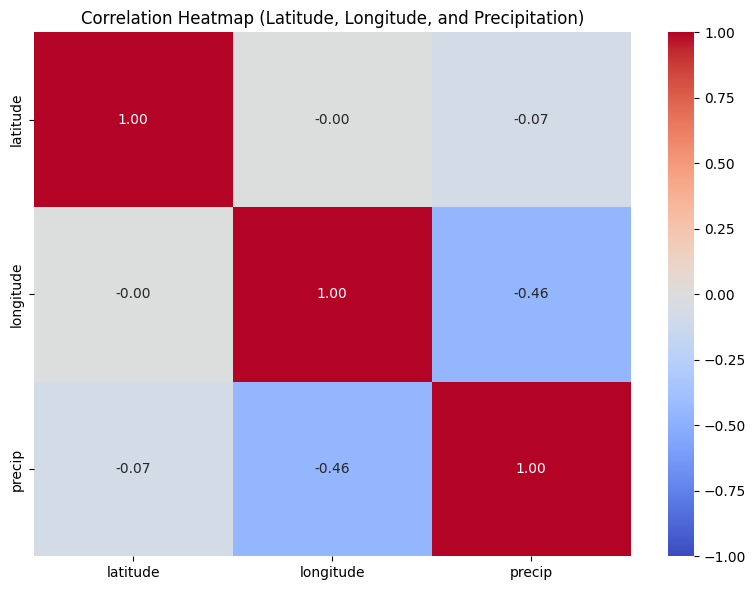

In [ ]:
import seaborn as sns
import numpy as np

# Calculate the correlation matrix for the relevant columns
corr_matrix = df[['latitude', 'longitude', 'precip']].corr()

# Plotting the correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Heatmap (Latitude, Longitude, and Precipitation)')
plt.tight_layout()
plt.show()


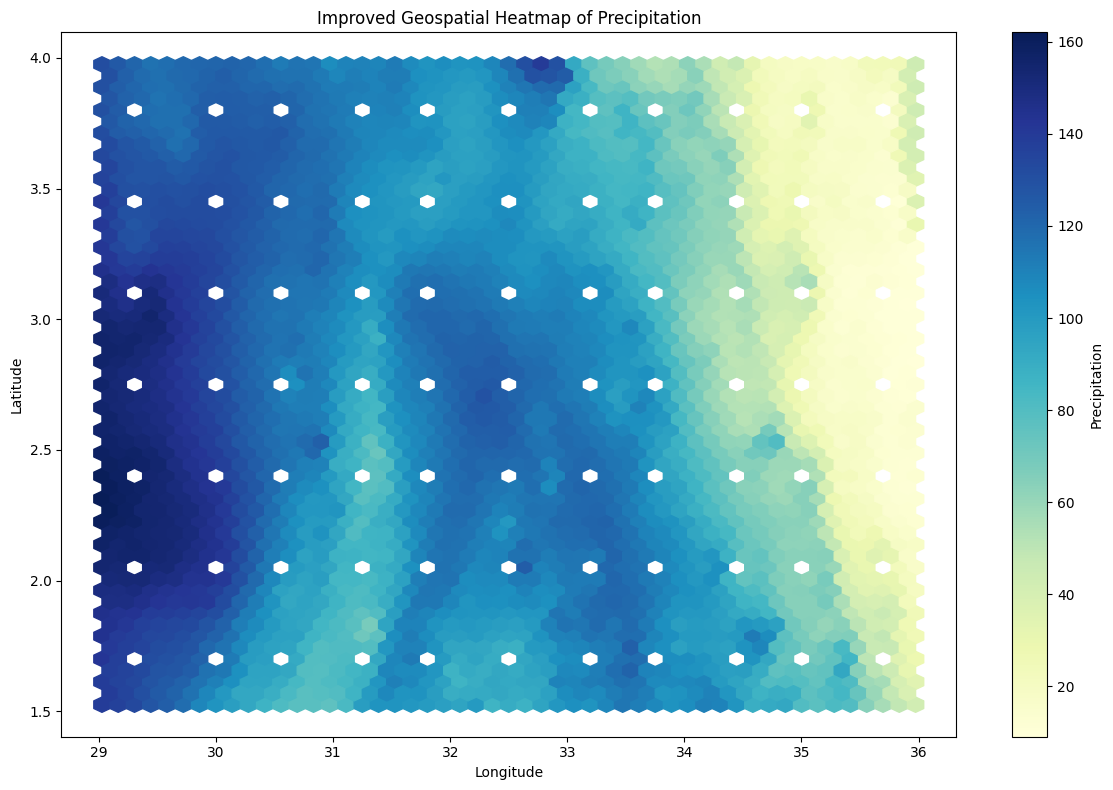

In [ ]:
# Improved Geospatial Heatmap using Hexbin
plt.figure(figsize=(12, 8))

# Using hexbin for better visualization of dense points
hb = plt.hexbin(df['longitude'], df['latitude'], C=df['precip'], gridsize=50, cmap='YlGnBu', mincnt=1)

# Add a color bar
cb = plt.colorbar(hb, label='Precipitation')

plt.title('Improved Geospatial Heatmap of Precipitation')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.show()



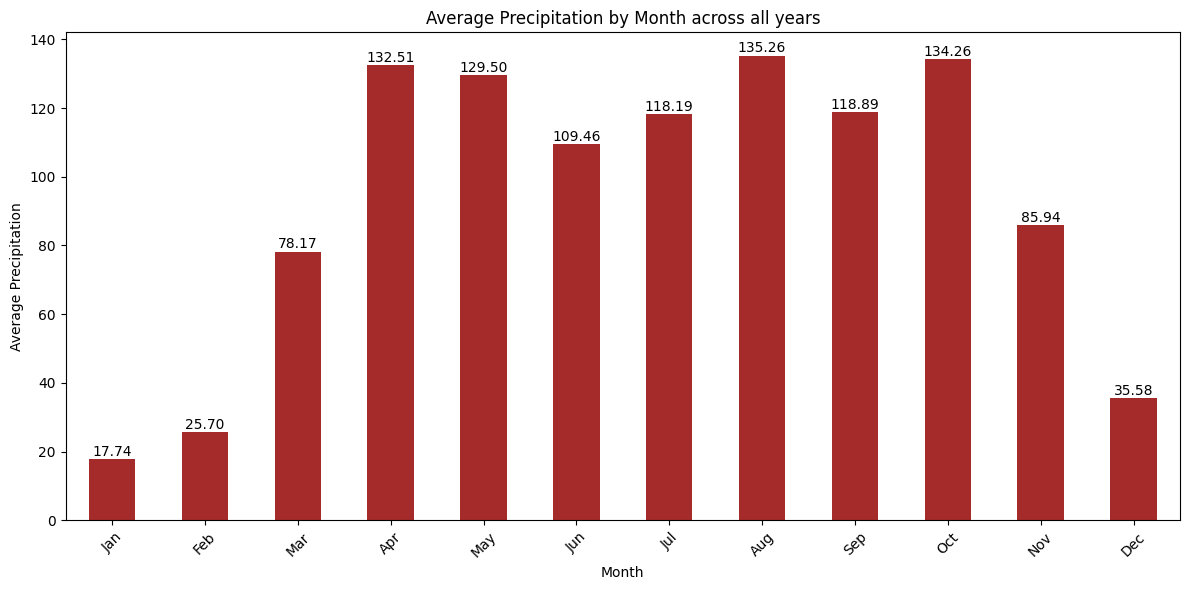

In [ ]:
# Grouping by month to calculate the average precipitation for each month across all years
monthly_precip_avg = df.groupby('month')['precip'].mean()

# Plotting the average precipitation for each month
plt.figure(figsize=(12, 6))
bars = monthly_precip_avg.plot(kind='bar', color='brown')

# Adding the average precipitation value on top of each bar
for i, value in enumerate(monthly_precip_avg):
    plt.text(i, value + 0.1, f'{value:.2f}', ha='center', va='bottom', fontsize=10)

plt.title('Average Precipitation by Month across all years')
plt.xlabel('Month')
plt.ylabel('Average Precipitation')
plt.xticks(range(12), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45)
plt.tight_layout()
plt.show()


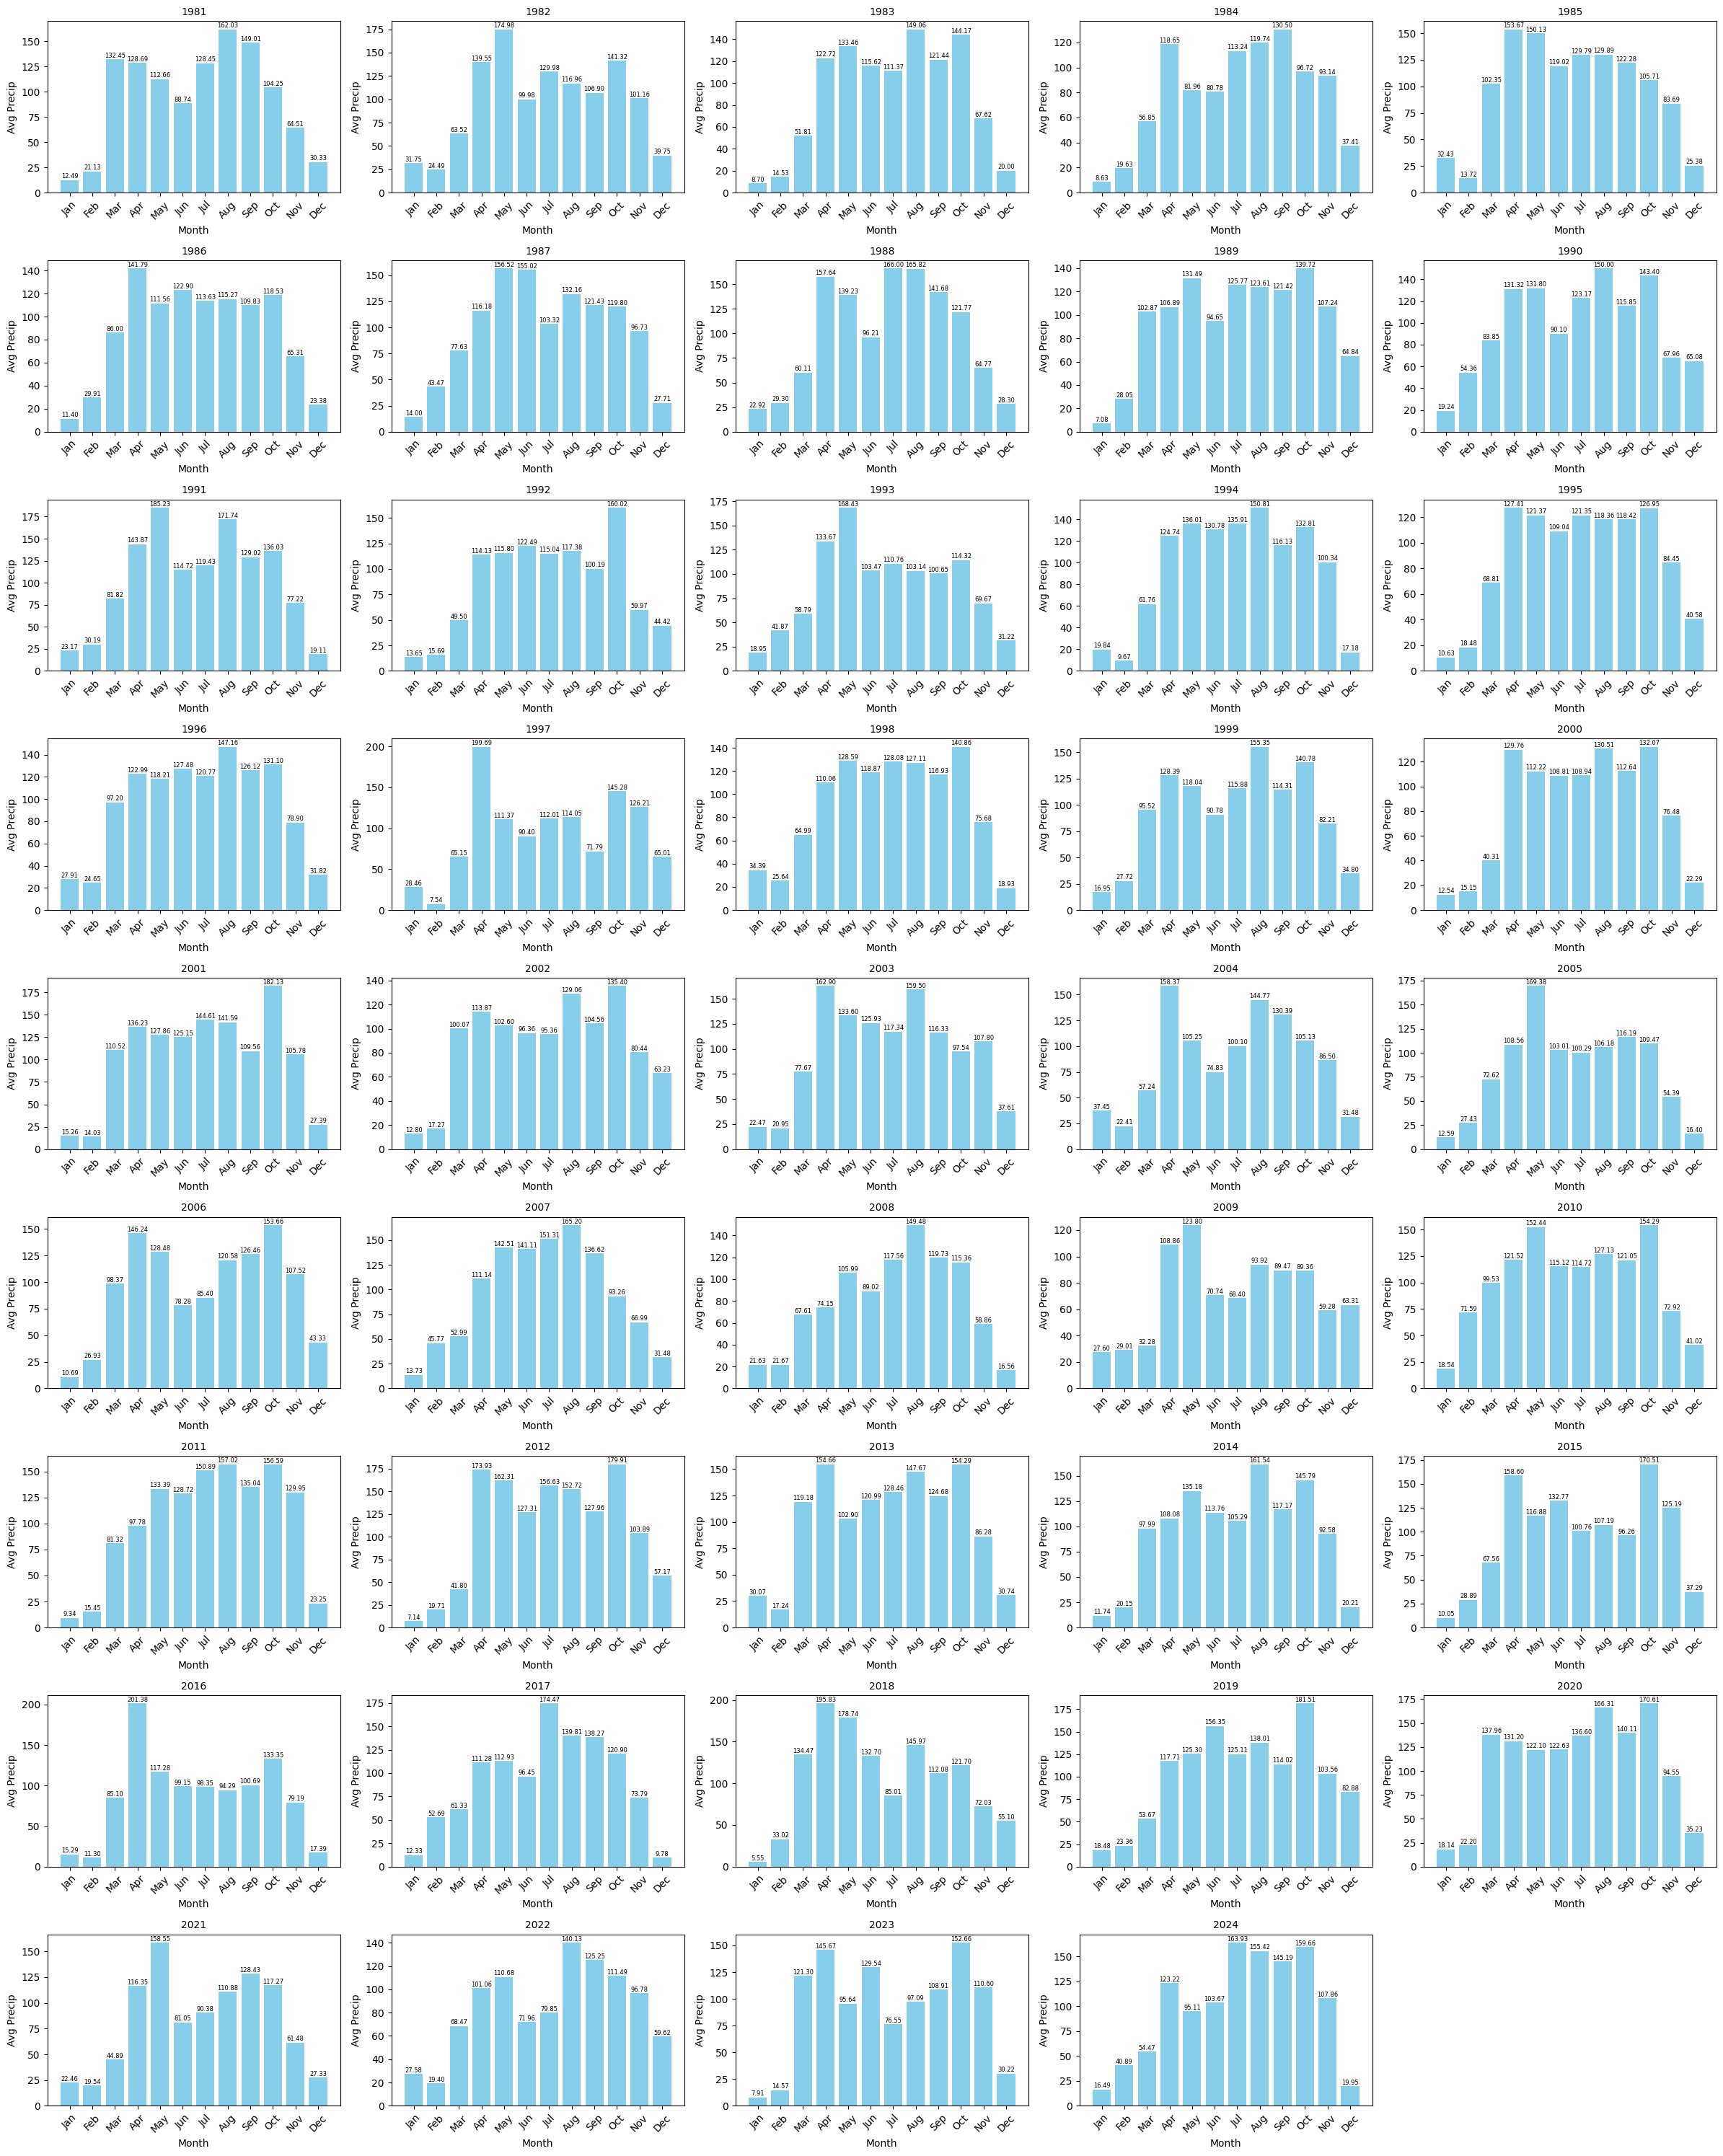

In [ ]:
import matplotlib.pyplot as plt

# Grouping by year and month to calculate the average precipitation
year_month_precip_avg = df.groupby(['year', 'month'])['precip'].mean().reset_index()

# Unique years
unique_years = year_month_precip_avg['year'].unique()

# Setting up the figure with a 9x5 grid
fig, axes = plt.subplots(9, 5, figsize=(24, 30))
axes = axes.flatten()

# Creating bar plots for each year
for i, year in enumerate(unique_years):
    data = year_month_precip_avg[year_month_precip_avg['year'] == year]

    ax = axes[i]
    bars = ax.bar(data['month'], data['precip'], color='skyblue')

    # Adding average precipitation value on top of each bar
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height + 0.2, f'{height:.2f}',
                ha='center', va='bottom', fontsize=6)

    ax.set_title(f'{year}', fontsize=10)
    ax.set_xlabel('Month')
    ax.set_ylabel('Avg Precip')
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                         'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

# Assuming lake_victoria_data is the original DataFrame
# Step 1: Extract Year, Month, and Period
df['Year'] = df['time'].dt.year
df['Month'] = df['time'].dt.strftime('%b')
df['Period'] = df['time'].dt.month

# Step 2: Aggregate data to get mean precipitation per month per year
monthly_data = df.groupby(['Month', 'Period', 'Year'])['precip'].mean().reset_index()

# Step 3: Pivot the data to have years as columns and months as rows
pivot_data = monthly_data.pivot_table(index=['Month', 'Period'], columns='Year', values='precip').reset_index()

# Step 4: Sort months correctly
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
pivot_data['Month'] = pd.Categorical(pivot_data['Month'], categories=month_order, ordered=True)
pivot_data = pivot_data.sort_values(by=['Period'])

# Step 5: Calculate the global monthly mean
pivot_data['chirps_global_1_monthly_mean'] = pivot_data.loc[:, pivot_data.columns[2:-1]].mean(axis=1)

# Step 6: Reorder columns to match the reference format
year_columns = sorted([col for col in pivot_data.columns if isinstance(col, int)])
cols = ['chirps_global_1_monthly_mean', 'Month', 'Period'] + year_columns
pivot_data = pivot_data[cols]

# Step 7: Save the transformed data to CSV in Google Drive
drive_path = '/content/drive/My Drive/capstone_data/Transformed_Lake_Victoria_Data.csv'
pivot_data.to_csv(drive_path, index=False)

print(f"Data saved to {drive_path}")


Data saved to /content/drive/My Drive/capstone_data/Transformed_Lake_Victoria_Data.csv


LAKE VICTORIA 5 YEARS MONTHLY TRENDS WITH SEVERAL LEAD TIMES.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xarray as xr
import os
import glob
import calendar

Processing model: CanESM5...


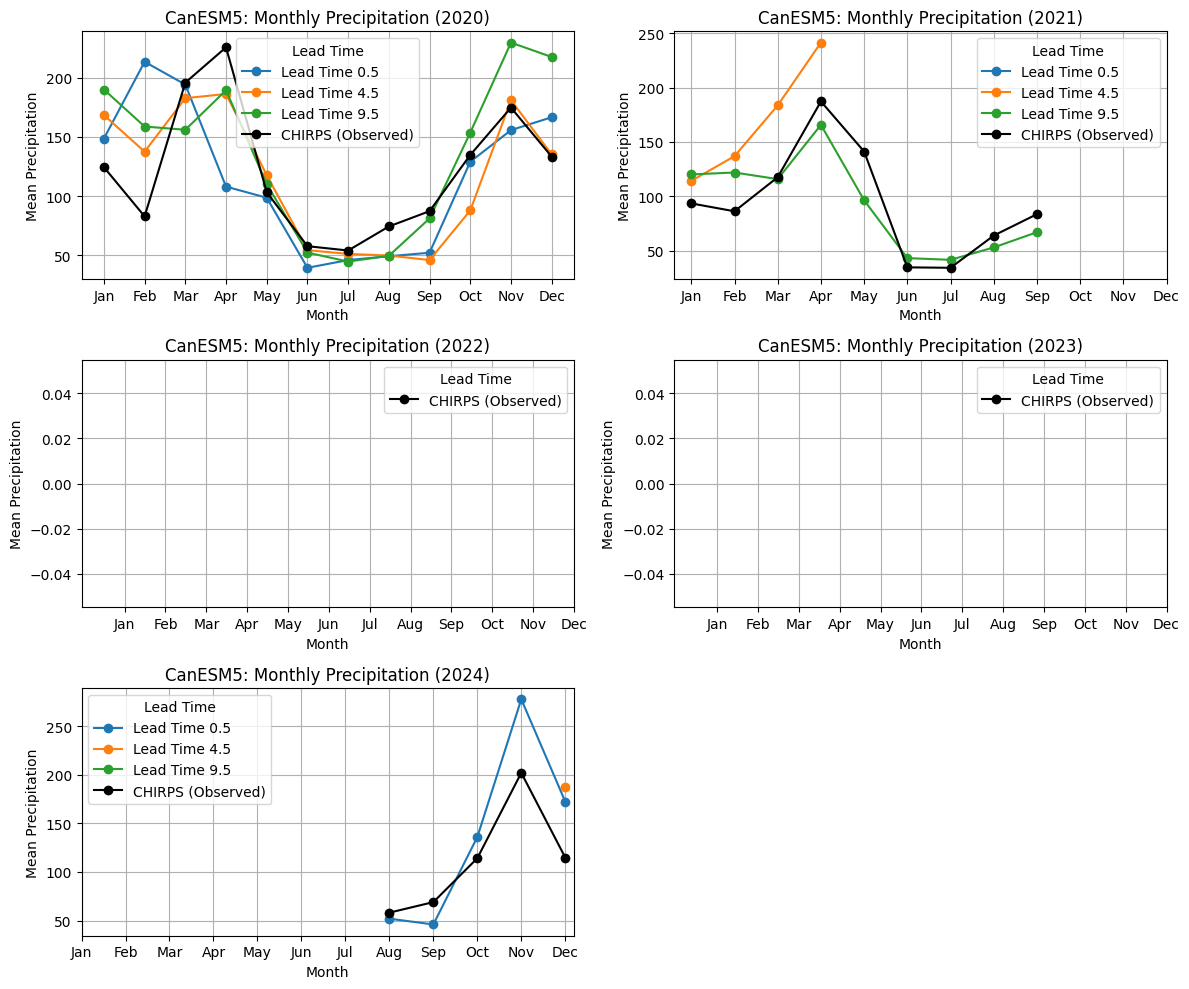

Processing model: CCSM4...


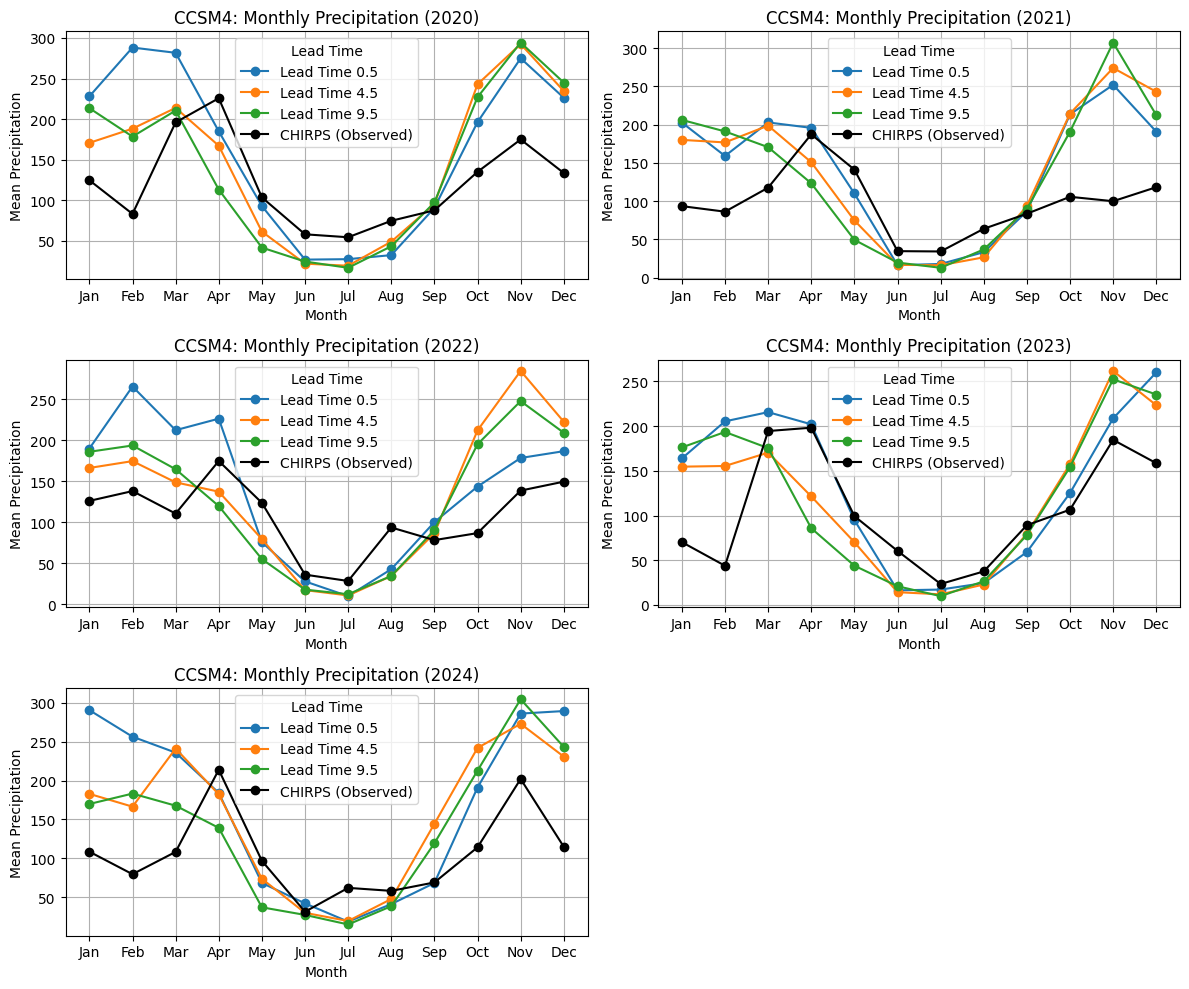

Processing model: CESM1...


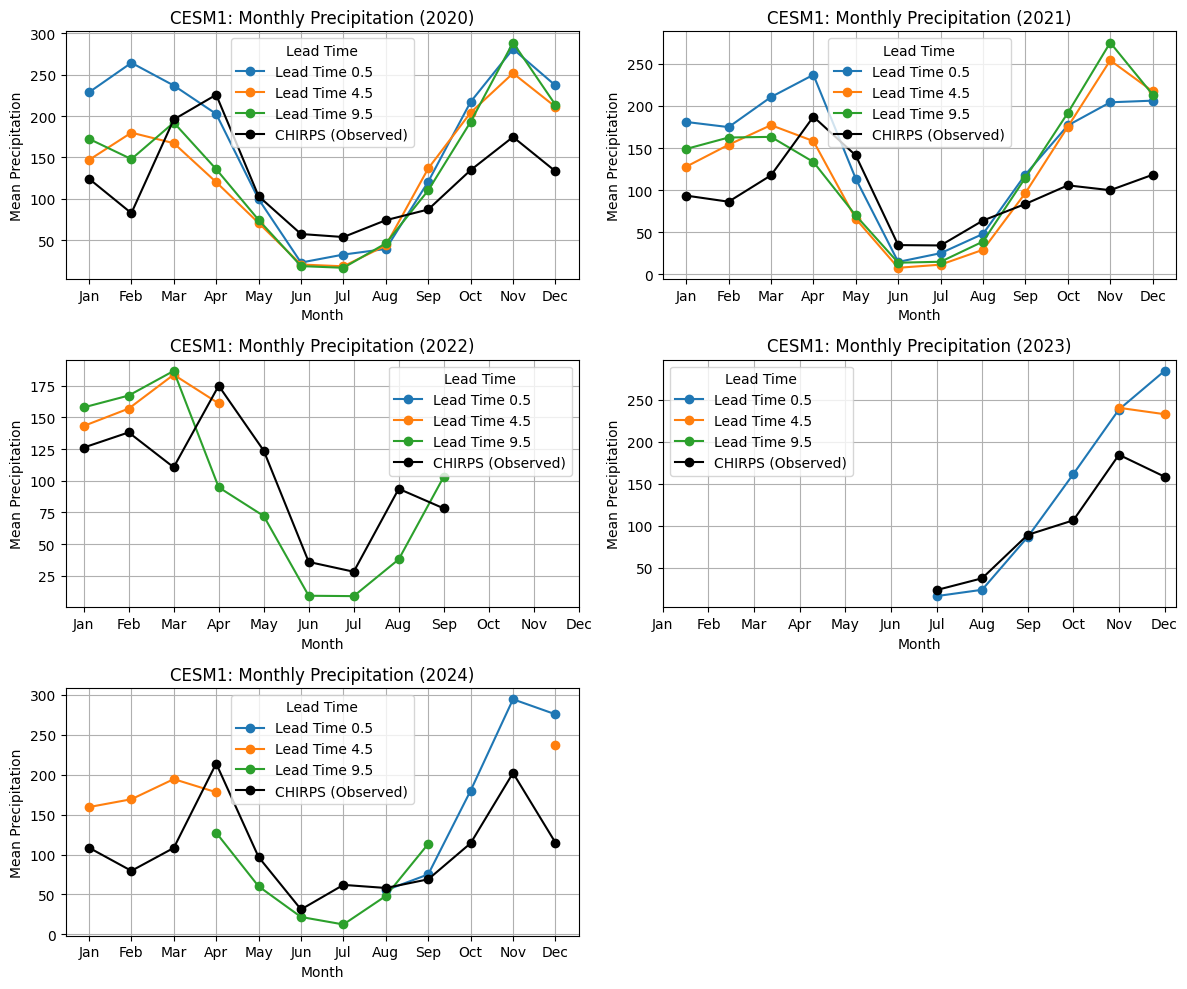

Processing model: GEM5...


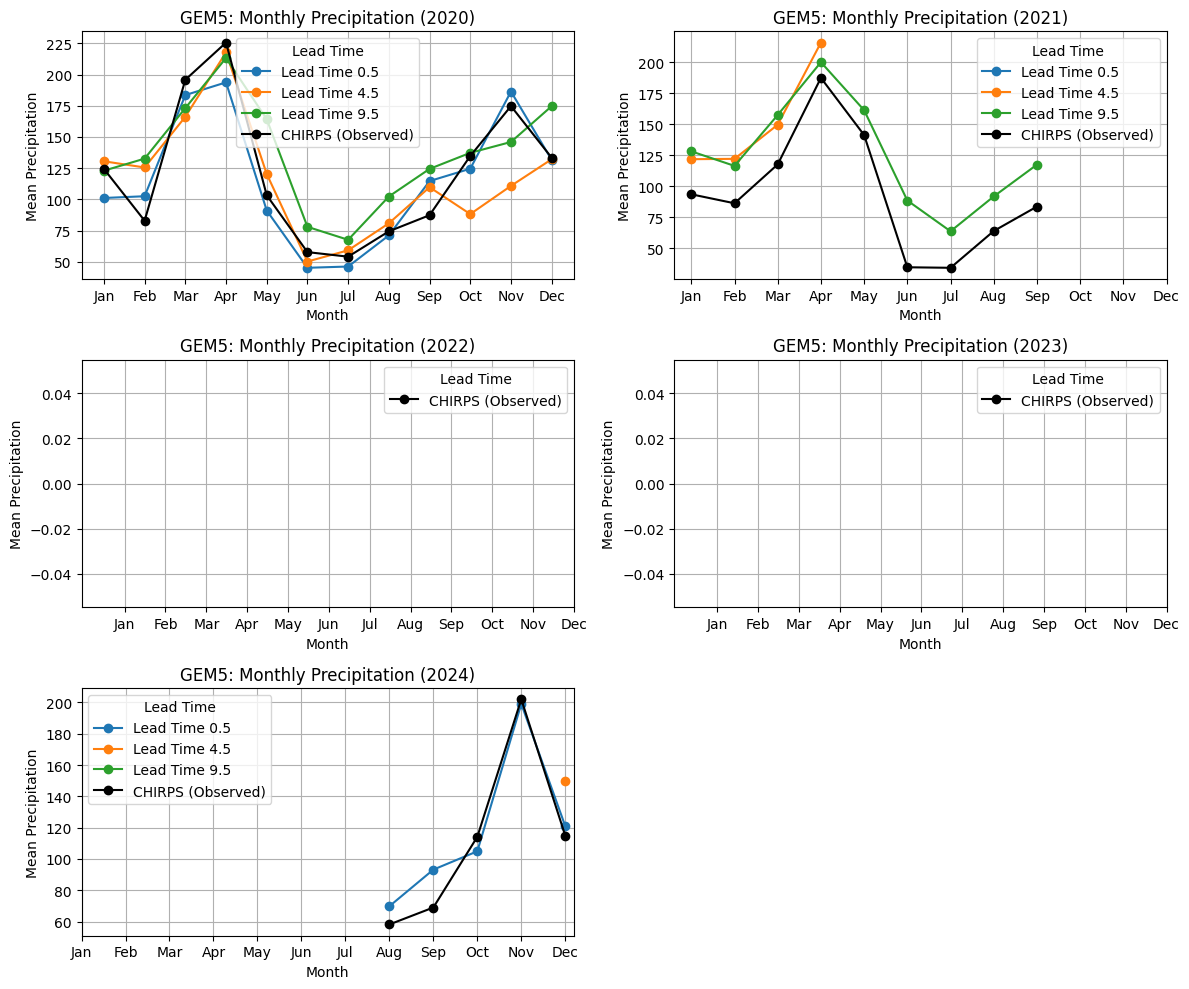

Processing model: NCEP...


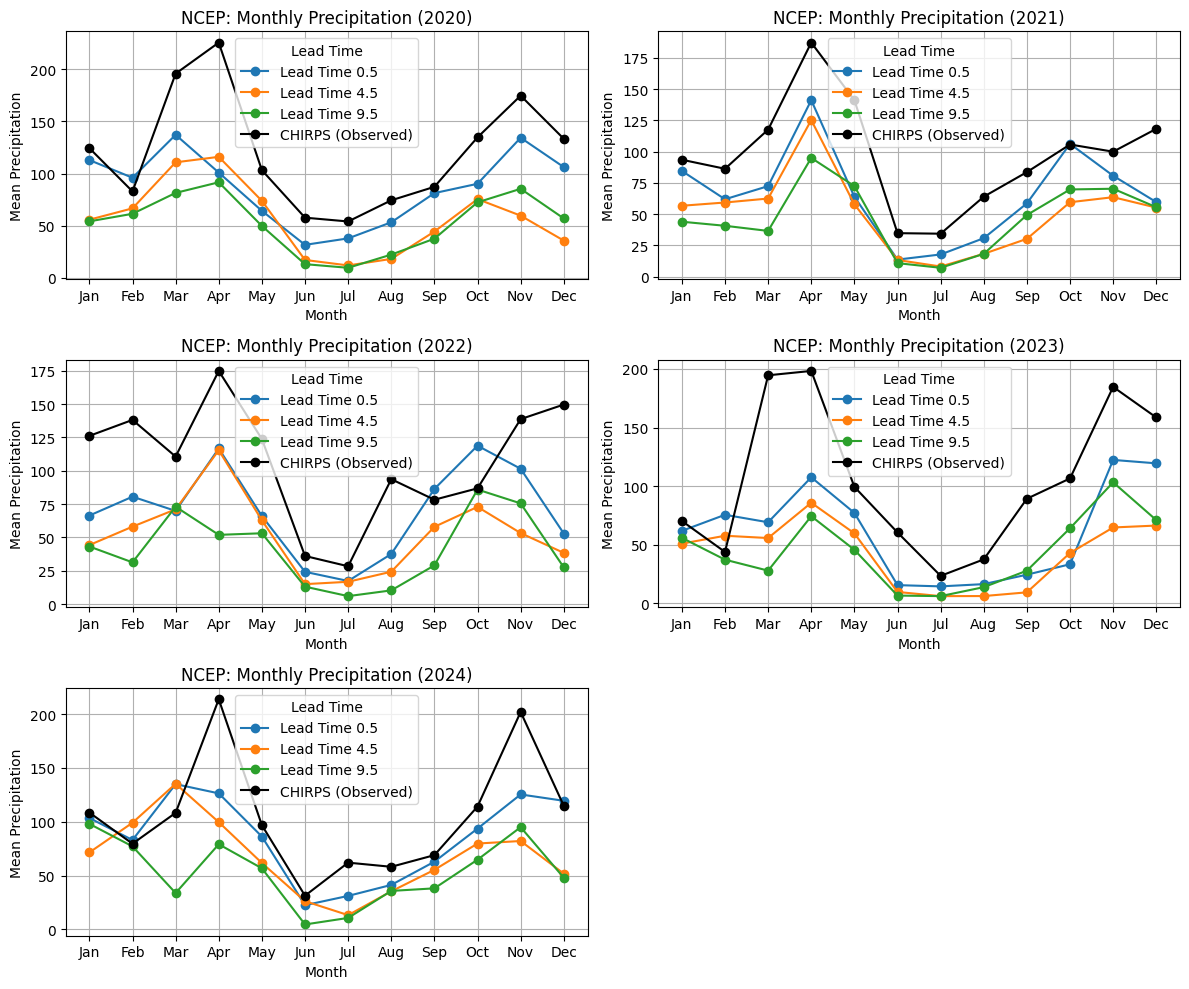

Processing model: DWD...


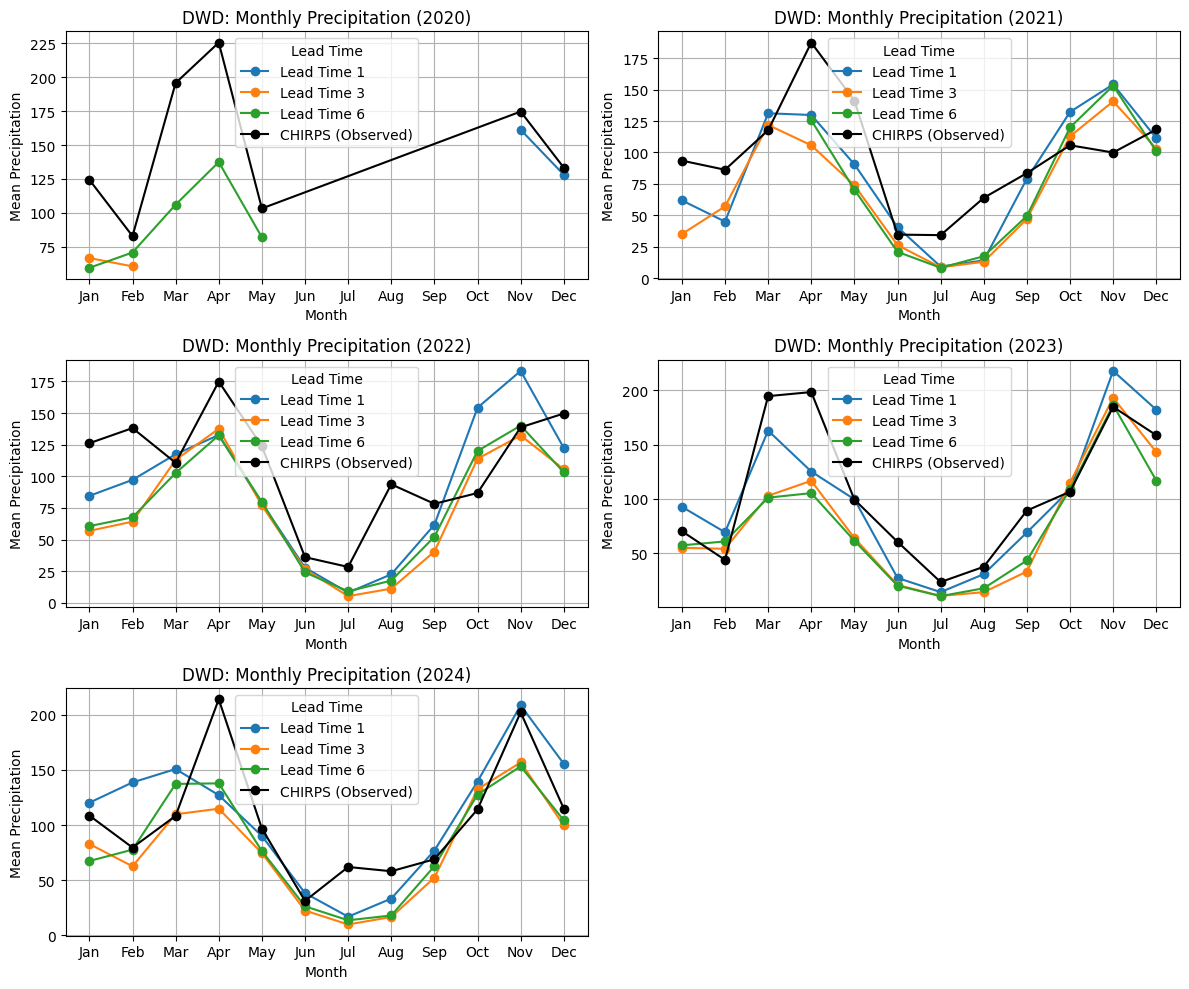

Processing model: METEO...


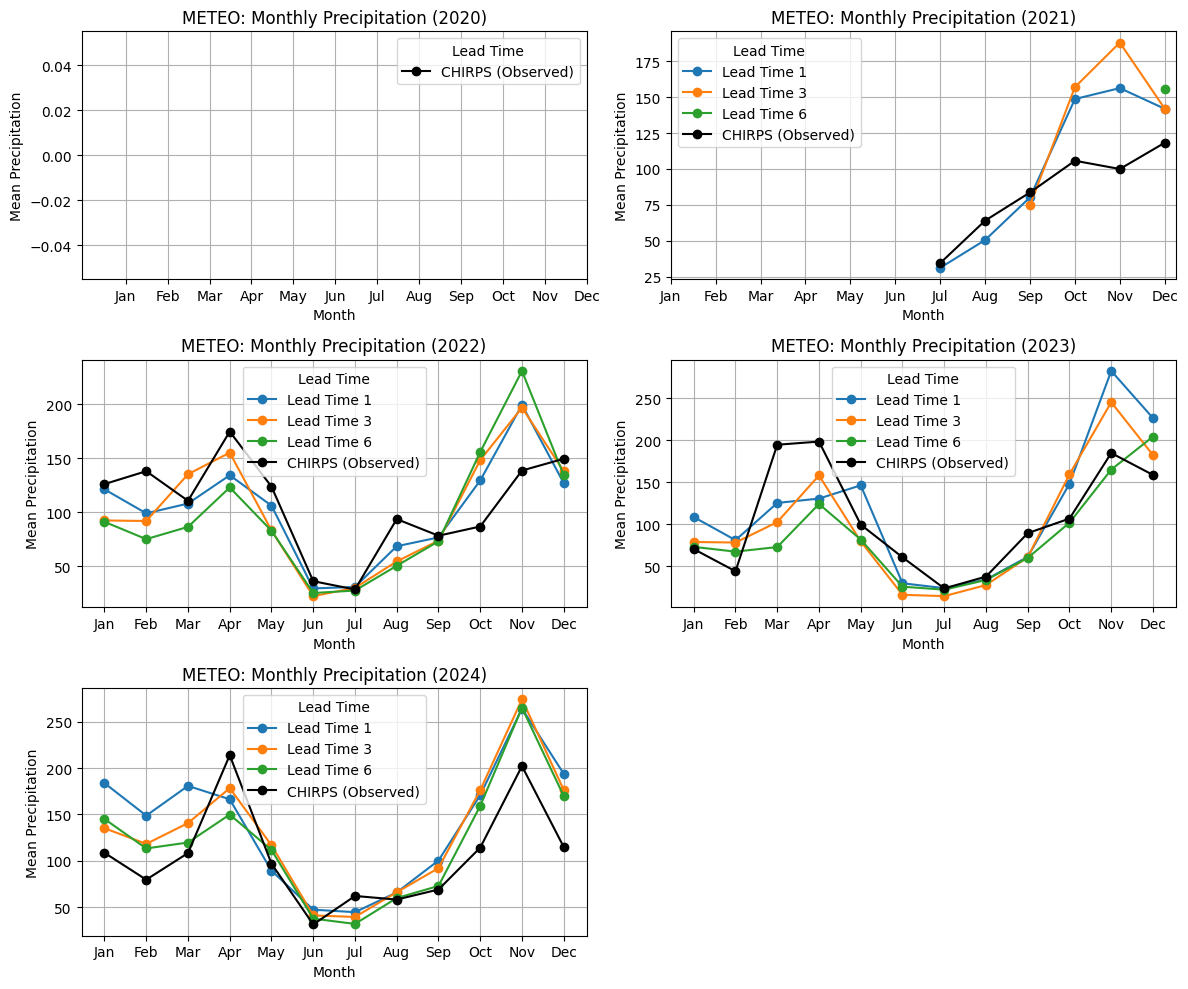

Processing model: ECMWF...


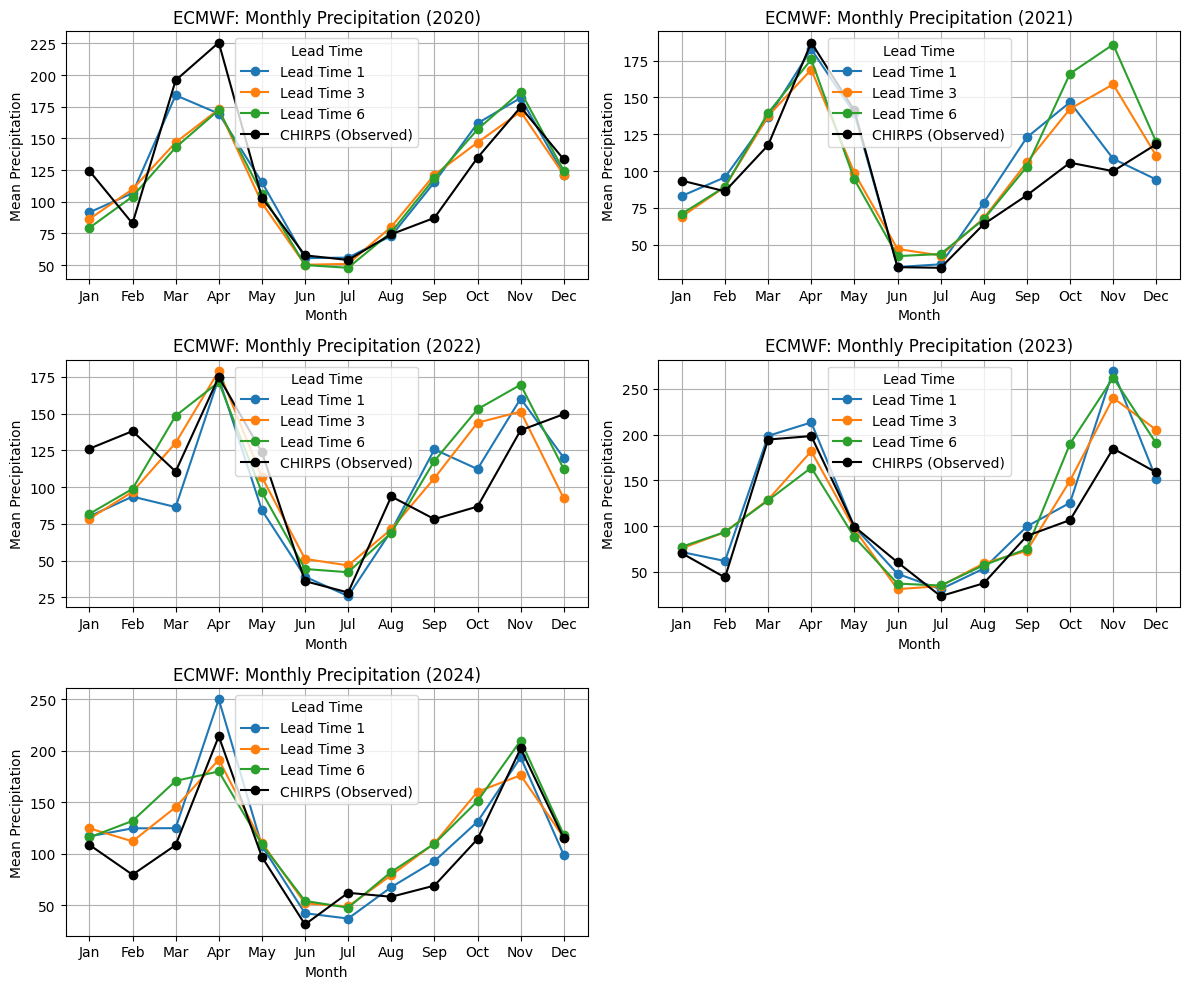

Processing model: GFDL...


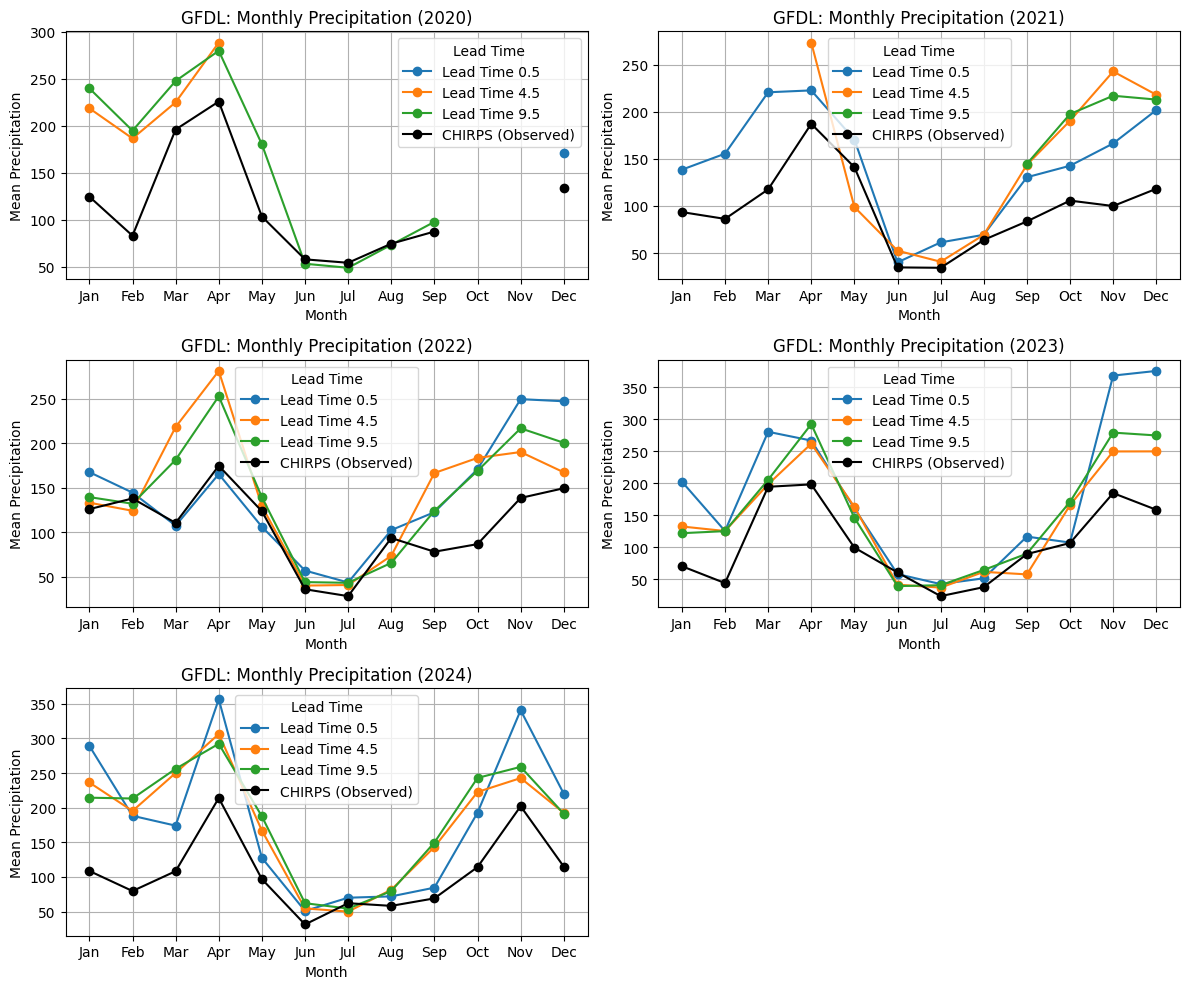

Processing model: NASA...


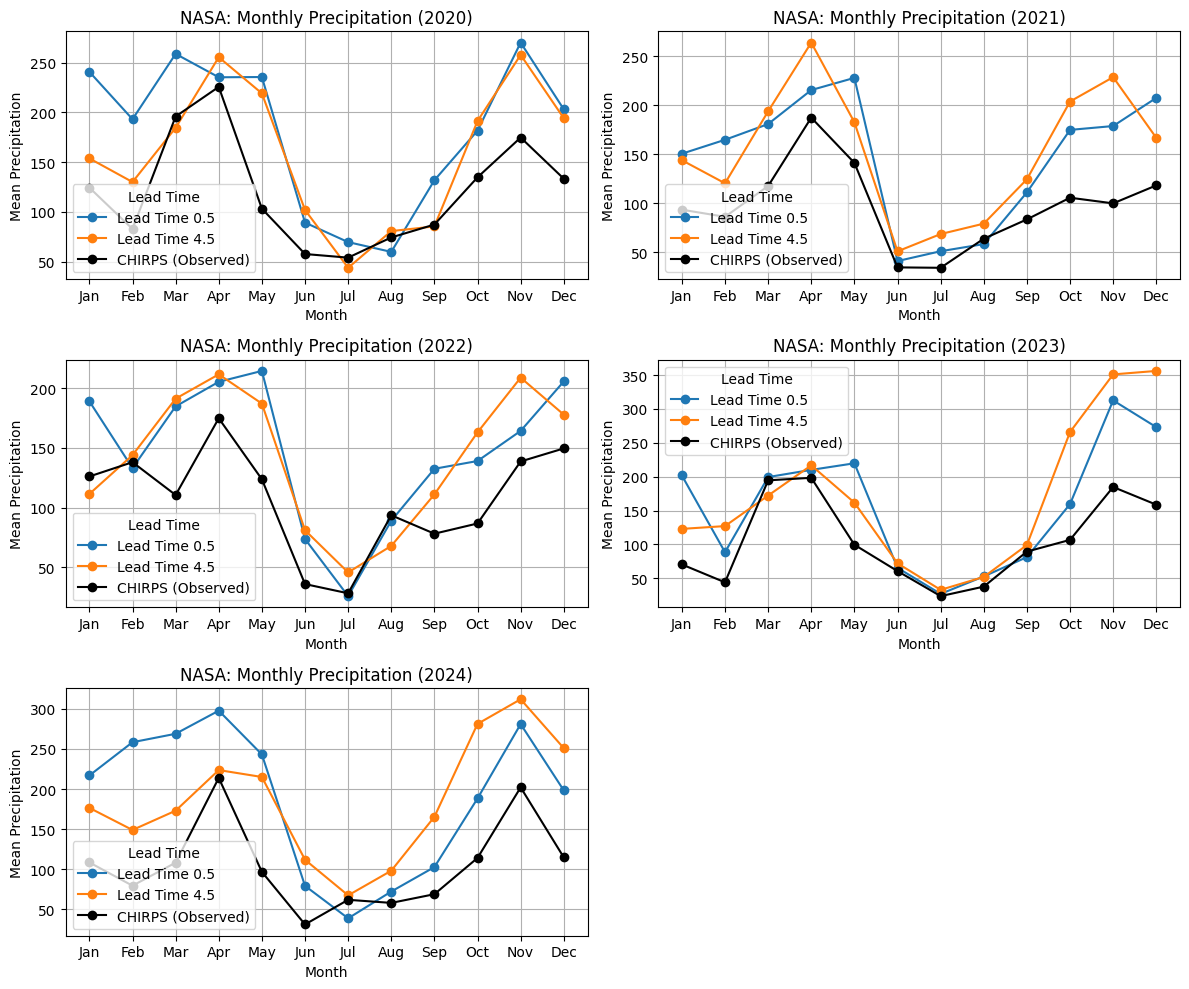

Processing model: CMCC...


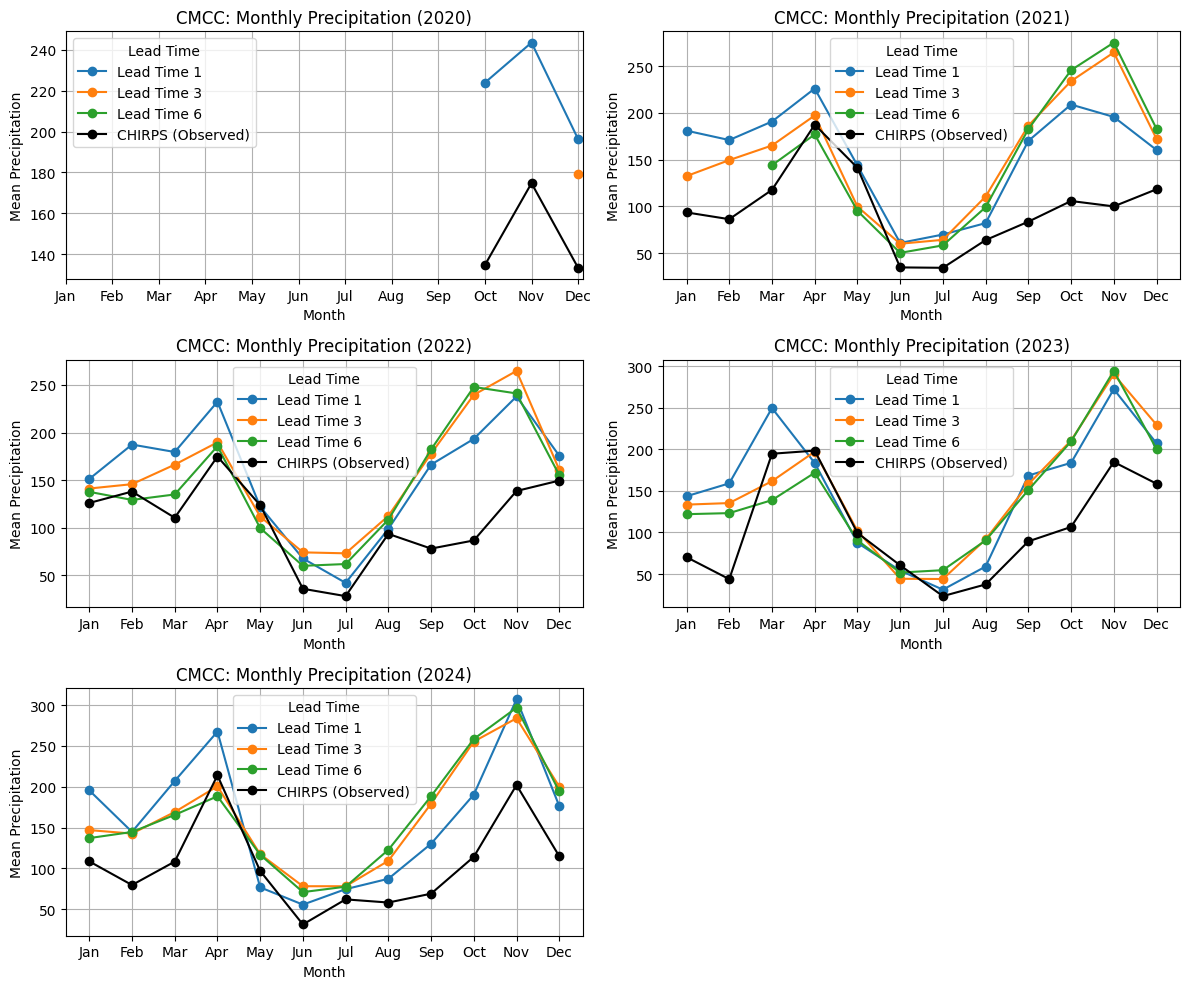

In [4]:
# Path to Lake Victoria Basin netCDF files
lake_victoria_path = '/content/drive/MyDrive/capstone_data/netCDF/'
nc_files = glob.glob(os.path.join(lake_victoria_path, "lake_victoria_basin_*.nc"))

# Years and lead times for analysis
years = [2020, 2021, 2022, 2023, 2024]
lead_times = [0.5, 1 ,3, 4.5, 6, 9.5]

# Initialize dictionaries to store wettest and driest months across models
wettest_months_all_models = {}
driest_months_all_models = {}

# Loop through each netCDF file (each model)
for nc_file in nc_files:
    model_name = os.path.basename(nc_file).replace("lake_victoria_basin_", "").replace("_merged.nc", "")
    print(f"Processing model: {model_name}...")

    # Open dataset
    dataset = xr.open_dataset(nc_file)

    # Extract precipitation data
    precip_data = dataset.to_dataframe().reset_index()

    # Ensure time format
    precip_data['time'] = pd.to_datetime(precip_data['time'])

    # Scale predicted precipitation
    precip_data['predicted_precip'] = precip_data['predicted_precip'] * 30

    # Dictionaries for this model
    wettest_months_dict = {}
    driest_months_dict = {}

    # Plot setup
    plt.figure(figsize=(12, 10))

    # Loop through years
    for i, year in enumerate(years, 1):
        yearly_data = precip_data[precip_data['time'].dt.year == year].copy()
        filtered_data = yearly_data[yearly_data['lead_time'].isin(lead_times)].copy()
        filtered_data.loc[:, 'month'] = filtered_data['time'].dt.month

        # Aggregate mean precipitation per month for each lead time
        monthly_precip = filtered_data.groupby(['lead_time', 'month'])['predicted_precip'].mean().unstack(level=0)

        # Compute monthly mean of CHIRPS observed precipitation
        monthly_precip['precip'] = filtered_data.groupby('month')['precip'].mean()

        # Create subplot for the year
        plt.subplot(3, 2, i)
        for lead_time in lead_times:
            if lead_time in monthly_precip.columns:
                plt.plot(monthly_precip.index, monthly_precip[lead_time], marker='o', linestyle='-', label=f'Lead Time {lead_time}')

        # Plot CHIRPS observed precipitation
        plt.plot(monthly_precip.index, monthly_precip["precip"], marker='o', linestyle='-', color='black', label="CHIRPS (Observed)")

        # Formatting the plot
        plt.xlabel('Month')
        plt.ylabel('Mean Precipitation')
        plt.title(f'{model_name}: Monthly Precipitation ({year})')
        plt.xticks(ticks=range(1, 13), labels=[calendar.month_abbr[m] for m in range(1, 13)])
        plt.legend(title="Lead Time")
        plt.grid(True)

        # Store wettest and driest months for this model
        #wettest_months_dict[year] = monthly_precip.idxmax()
        #driest_months_dict[year] = monthly_precip.idxmin()

    # Adjust layout and show plot for this model
    plt.tight_layout()
    plt.show()
